# 📋 P3 — Instruction Following Benchmark
## prompt-engineering-lab by ChuksForge

**Goal:** Measure how reliably models follow explicit instructions across three failure-prone categories.

| | |
|---|---|
| **Categories** | Multi-Step · Tone & Persona · Negation Handling |
| **Tasks** | 18 tasks (6 per category, easy/medium/hard) |
| **Models** | GPT-4o-mini · GPT-4o · Claude Haiku · Claude Sonnet 4.6 · Mistral 7B · Llama 3 8B |
| **Scoring** | Programmatic constraint rubric — no LLM judge needed |
| **Output** | Pass rate · Full compliance % · Failure taxonomy |

---

In [1]:
# !pip install openai anthropic pandas numpy matplotlib
import os, pandas as pd, matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120
# os.environ['OPENAI_API_KEY']    = 'sk-...'
# os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...'
# os.environ['OPENROUTER_API_KEY'] = 'sk-or-...'
print('Setup complete')

Setup complete


## 1. Preview Tasks

In [2]:
tasks = pd.read_csv('data/tasks.csv')
print(f'{len(tasks)} tasks | Categories: {tasks["category"].unique()}')
print(f'Difficulty split:\n{tasks.groupby(["category","difficulty"]).size().unstack()}')
tasks[['task_id','category','difficulty','instruction']].head(6)

18 tasks | Categories: <StringArray>
['multi_step', 'tone_persona', 'negation']
Length: 3, dtype: str
Difficulty split:
difficulty    easy  hard  medium
category                        
multi_step       2     2       2
negation         2     2       2
tone_persona     2     2       2


,task_id,category,difficulty,instruction
0,MS01,multi_step,easy,Do the following three things: 1) Write a one-...
1,MS02,multi_step,easy,Complete these steps in order: 1) Name the cap...
2,MS03,multi_step,medium,You are given a business problem: a small bake...
3,MS04,multi_step,medium,Analyze the following product review and do ea...
4,MS05,multi_step,hard,You are a financial advisor. A client asks abo...
5,MS06,multi_step,hard,Write a product announcement for a new AI writ...


In [3]:
# Inspect a hard task's constraints
import json
task = tasks[tasks['task_id'] == 'NG05'].iloc[0]
print(f'Task: {task["task_id"]} ({task["category"]}, {task["difficulty"]})')
print(f'Instruction:\n{task["instruction"]}\n')
print('Constraints:')
for c in json.loads(task['constraints_json']):
    print(f'  {c}')

Task: NG05 (negation, hard)
Instruction:
Write a short story (100-150 words) about a detective solving a mystery. Rules: Do NOT use the words 'clue', 'evidence', 'suspect', or 'crime'. Do NOT reveal the solution in the final sentence. The story must end on an ambiguous note.

Constraints:
  {'type': 'word_absent', 'words': ['clue', 'evidence', 'suspect', 'crime']}
  {'type': 'word_count_min', 'min': 100}
  {'type': 'word_count_max', 'max': 150}
  {'type': 'tone_word_absent', 'words': ['the mystery was solved|he had done it|she confessed|the answer was|it was', 'all along']}


## 5. Explore Results

In [4]:
df  = pd.read_csv('results/results.csv')
lb  = pd.read_csv('results/leaderboard.csv')
fr  = pd.read_csv('results/failure_report.csv')
df  = df[df['error'].isna() | (df['error'] == '')].copy()
print('Leaderboard (OVERALL):')
lb[lb['category']=='OVERALL'][['model','avg_pass_rate','compliance_rate','tasks_run']]

Leaderboard (OVERALL):


,model,avg_pass_rate,compliance_rate,tasks_run
0,GPT-4o-mini,0.9667,0.8333,18
1,Claude Sonnet 4.6,0.9528,0.7778,18
2,Claude Haiku,0.9482,0.8333,18
3,GPT-4o,0.9417,0.7778,18
4,Llama 3 8B,0.9278,0.7222,18
5,Mistral small creative,0.8880,0.6667,18


In [5]:
# Failure analysis
print('Failure mode breakdown:')
fr.groupby('failure_mode')['count'].sum().sort_values(ascending=False)

Failure mode breakdown:


failure_mode
LENGTH_VIOLATION     11
WRONG_FORMAT          8
MISSED_STEP           7
VIOLATED_NEGATION     2
WRONG_TONE            1
Name: count, dtype: int64

In [6]:
# Tasks where all models failed (hardest tasks)
task_avg = df.groupby('task_id')['pass_rate'].mean().sort_values()
print('5 hardest tasks (lowest avg pass rate):')
print(task_avg.head())
print('\n5 easiest tasks:')
print(task_avg.tail())

5 hardest tasks (lowest avg pass rate):
task_id
MS06    0.666667
TP05    0.800000
MS05    0.866667
NG05    0.875000
NG04    0.888900
Name: pass_rate, dtype: float64

5 easiest tasks:
task_id
TP02    1.0
TP03    1.0
MS04    1.0
TP04    1.0
TP06    1.0
Name: pass_rate, dtype: float64


## 6. Generate Charts

In [7]:
from visualize import generate_all_charts
generate_all_charts()


 Generating charts...
  108 rows | 6 models | 18 tasks

  ✓ results\chart_leaderboard.png
  ✓ results\chart_by_category.png
  ✓ results\chart_by_difficulty.png
  ✓ results\chart_failure_modes.png
  ✓ results\chart_task_heatmap.png
  ✓ results\charts.png  ← README hero

 All charts saved to results/


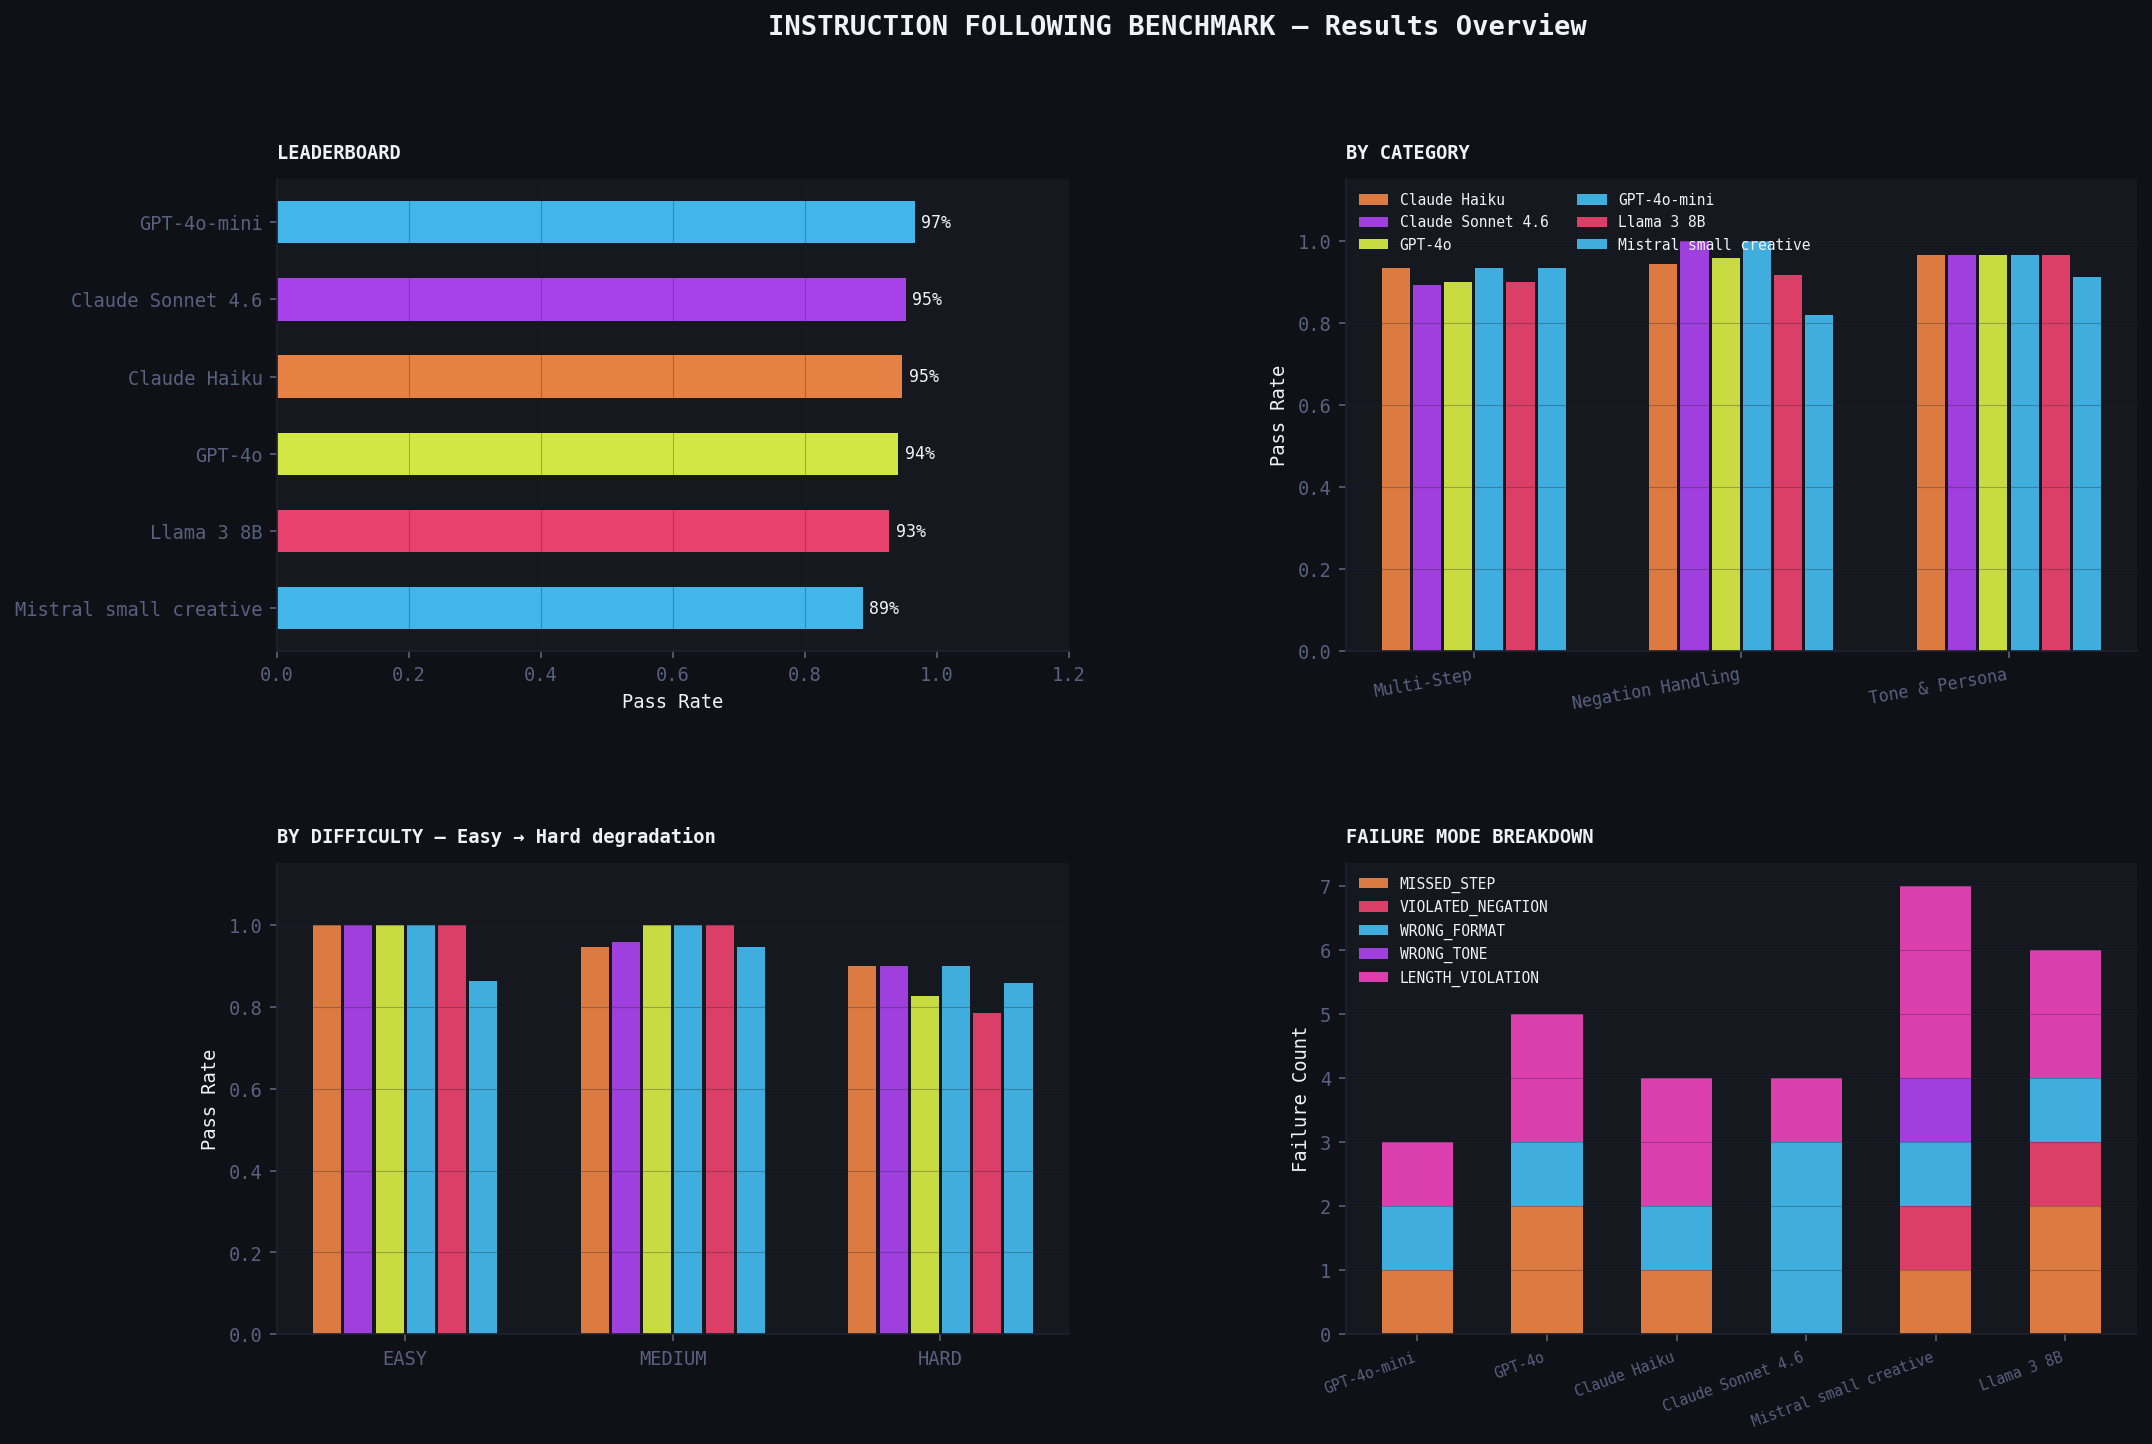

In [8]:
from IPython.display import Image
Image('results/charts.png')

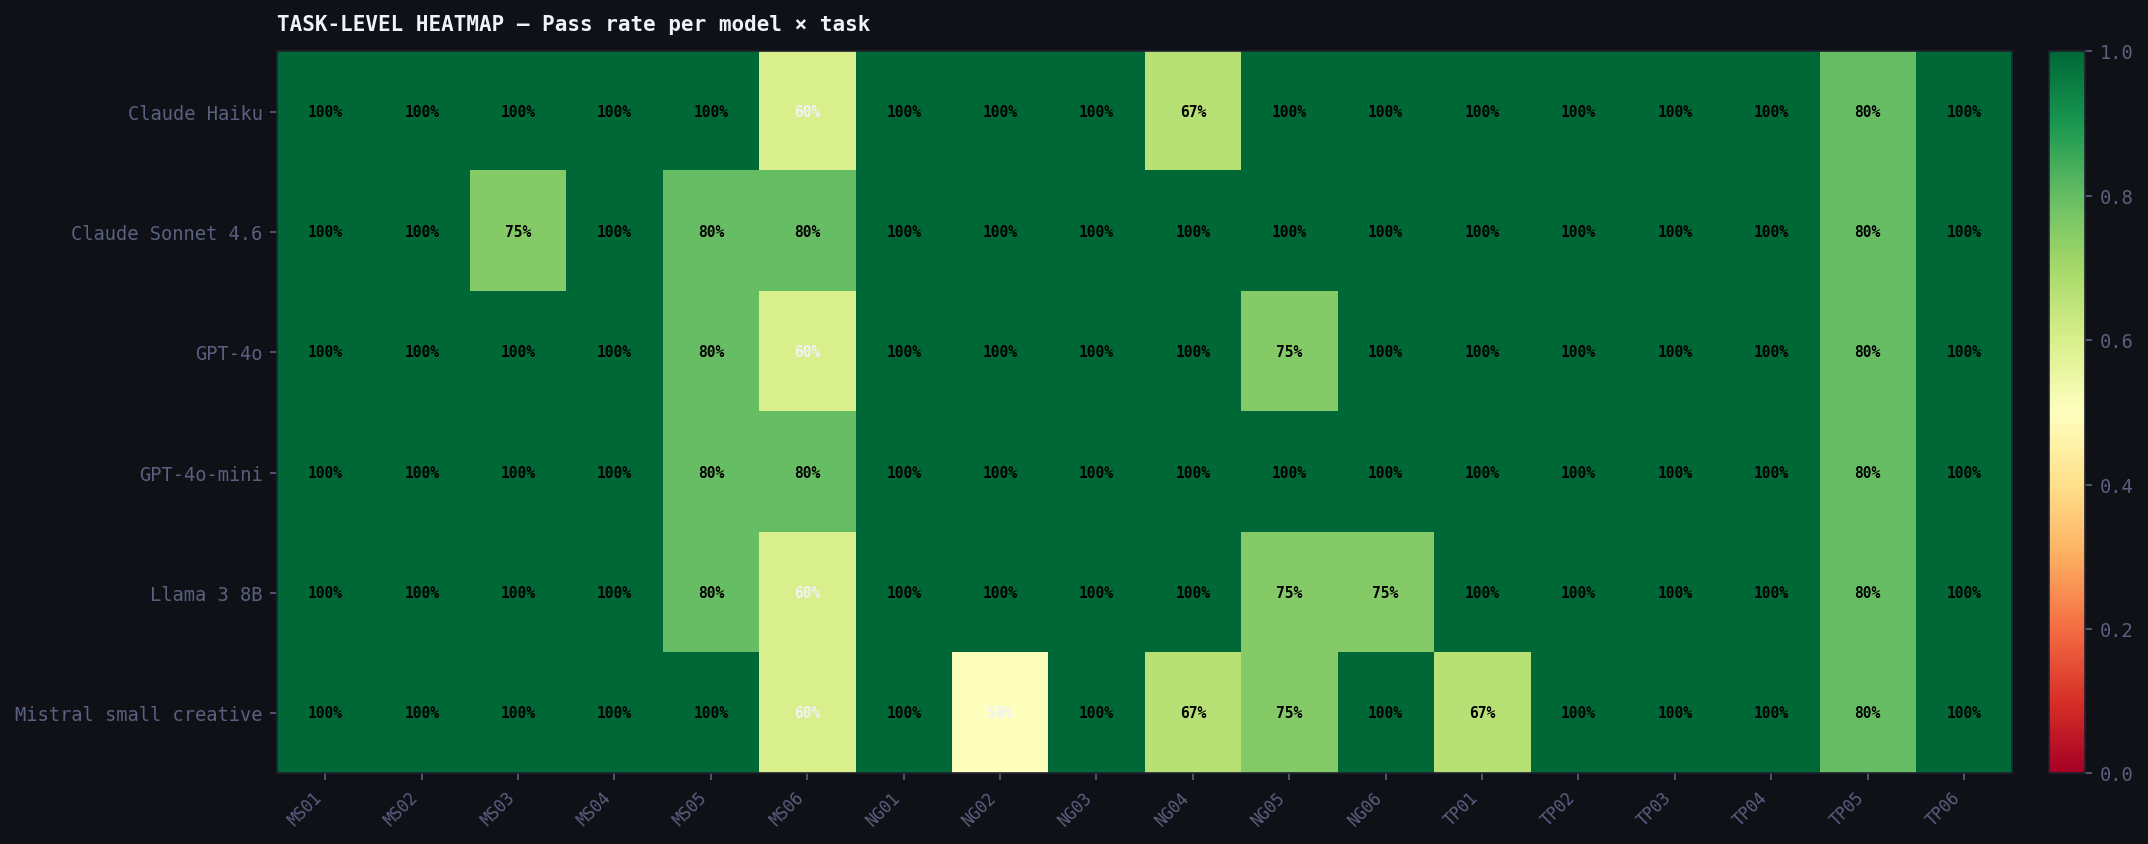

In [9]:
Image('results/chart_task_heatmap.png')

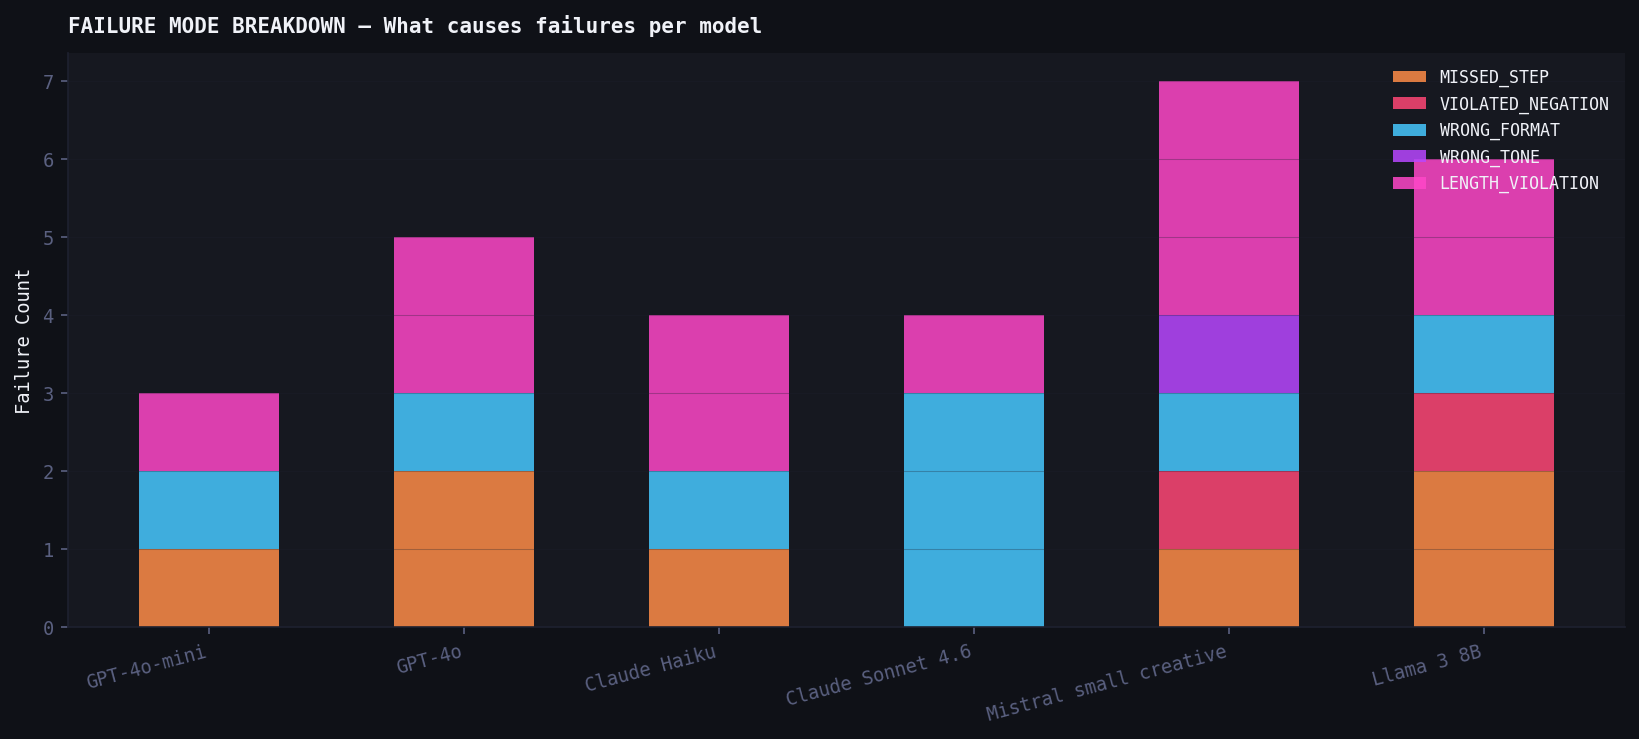

In [10]:
Image('results/chart_failure_modes.png')

## 7. Auto-Populate README & Findings

In [11]:
# Run this to update README.md and print key findings
# Copy the printed block below into Cell 8
import subprocess
subprocess.run(['python', 'update_findings.py'])

CompletedProcess(args=['python', 'update_findings.py'], returncode=0)

## 8. Key Findings

*Run `python update_findings.py` and paste the output here.*

## Key Findings

1. **Best model overall:** `GPT-4o-mini` — 96.7% avg pass rate, 83.3% full compliance
2. **Worst model overall:** `Mistral small creative` — 88.8% avg pass rate
3. **Hardest category:** `Multi-Step` — 91.5% avg pass rate
4. **Easiest category:** `Tone & Persona` — 95.7% avg pass rate
5. **Difficulty gap:** Easy=97.7% → Hard=86.1% — 11.6% drop in pass rate
6. **Most common failure mode:** `LENGTH_VIOLATION` — 38% of all failures
7. **Key insight:** [Fill in after reviewing failure_report.csv and task heatmap]
- Claude Sonnet 4.6 is unusually format-constrained — 75% of its failures are WRONG_FORMAT, the highest format failure rate of any model. It gets the logic right but struggles to comply with output structure requirements.
- LENGTH_VIOLATION is the universal failure mode — it appears across every single model, making it the most systemic weakness in the benchmark. Models consistently overshoot or undershoot length targets.
- Mistral small creative is the most failure-diverse — it's the only model hitting 5 distinct failure types including WRONG_TONE and VIOLATED_NEGATION, suggesting it misunderstands task constraints at a conceptual level, not just a formatting level.
- The heatmap masks a nuanced failure story — models like GPT-4o and Llama 3 8B look visually competitive (mostly dark green), but their failure breakdowns show structural issues in specific task types.
---
*See `results/failure_report.csv` for per-model failure breakdown.*
*See `results/chart_task_heatmap.png` for task-level pass rates.*
